# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Real Diabetes Lab Results Dataset](https://www.kaggle.com/datasets/rahibvk/real-diabetes-lab-results-and-biomarkers-anti-pima/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('custom_multi_year_diabetes_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,HbA1c_Level,Diabetes_Status,Source_Year
0,69.0,Male,26.7,122.0,72.0,13.9,2,2013-2014
1,54.0,Male,28.6,156.0,62.0,9.1,2,2013-2014
2,72.0,Male,28.9,140.0,90.0,8.9,2,2013-2014
3,73.0,Female,19.7,136.0,86.0,4.9,0,2013-2014
4,56.0,Male,41.7,160.0,84.0,5.5,0,2013-2014


## last Five row

In [4]:
df.tail()

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,HbA1c_Level,Diabetes_Status,Source_Year
20106,70.0,Female,20.0,136.0,74.0,7.4,1,2017-2018
20107,42.0,Male,35.8,124.0,76.0,5.9,0,2017-2018
20108,41.0,Female,26.1,116.0,66.0,5.2,0,2017-2018
20109,14.0,Female,45.6,114.0,62.0,5.5,0,2017-2018
20110,38.0,Male,36.1,150.0,98.0,5.4,0,2017-2018


## Shape of our dataset

In [5]:
df.shape

(20111, 8)

## List out all columns

In [6]:
df.columns

Index(['Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'HbA1c_Level',
       'Diabetes_Status', 'Source_Year'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Age                float64
Gender              object
BMI                float64
Systolic_BP        float64
Diastolic_BP       float64
HbA1c_Level        float64
Diabetes_Status      int64
Source_Year         object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20111 entries, 0 to 20110
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              20111 non-null  float64
 1   Gender           20111 non-null  object 
 2   BMI              19834 non-null  float64
 3   Systolic_BP      18409 non-null  float64
 4   Diastolic_BP     18409 non-null  float64
 5   HbA1c_Level      19001 non-null  float64
 6   Diabetes_Status  20111 non-null  int64  
 7   Source_Year      20111 non-null  object 
dtypes: float64(5), int64(1), object(2)
memory usage: 1.2+ MB


## Check Null Value

In [9]:
df.isnull().sum()

Age                   0
Gender                0
BMI                 277
Systolic_BP        1702
Diastolic_BP       1702
HbA1c_Level        1110
Diabetes_Status       0
Source_Year           0
dtype: int64

## Fill missing numerical values with median

In [10]:
df["BMI"] = df["BMI"].fillna(df["BMI"].median())
df["Systolic_BP"] = df["Systolic_BP"].fillna(df["Systolic_BP"].median())
df["Diastolic_BP"] = df["Diastolic_BP"].fillna(df["Diastolic_BP"].median())
df["HbA1c_Level"] = df["HbA1c_Level"].fillna(df["HbA1c_Level"].median())

## Fill missing categorical values with mode (if any exist)

In [11]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Source_Year"] = df["Source_Year"].fillna(df["Source_Year"].mode()[0])

## Check remaining missing values

In [12]:
print(df.isnull().sum())

Age                0
Gender             0
BMI                0
Systolic_BP        0
Diastolic_BP       0
HbA1c_Level        0
Diabetes_Status    0
Source_Year        0
dtype: int64


## Check Dupicate Value

In [13]:
df.duplicated().sum()

np.int64(4)

## Summary

In [14]:
df.describe()

,Age,BMI,Systolic_BP,Diastolic_BP,HbA1c_Level,Diabetes_Status
count,20111.000000,20111.000000,20111.000000,2.011100e+04,20111.000000,20111.000000
mean,43.452439,28.512088,121.743623,6.842604e+01,5.705569,0.260355
std,20.902683,7.309317,17.862592,1.316736e+01,1.022737,0.654889
min,12.000000,13.200000,66.000000,5.397605e-79,3.500000,0.000000
25%,24.000000,23.400000,110.000000,6.200000e+01,5.200000,0.000000
50%,43.000000,27.400000,118.000000,6.800000e+01,5.500000,0.000000
75%,61.000000,32.200000,130.000000,7.600000e+01,5.800000,0.000000
max,80.000000,86.200000,236.000000,1.360000e+02,17.500000,2.000000


# EDA

In [15]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

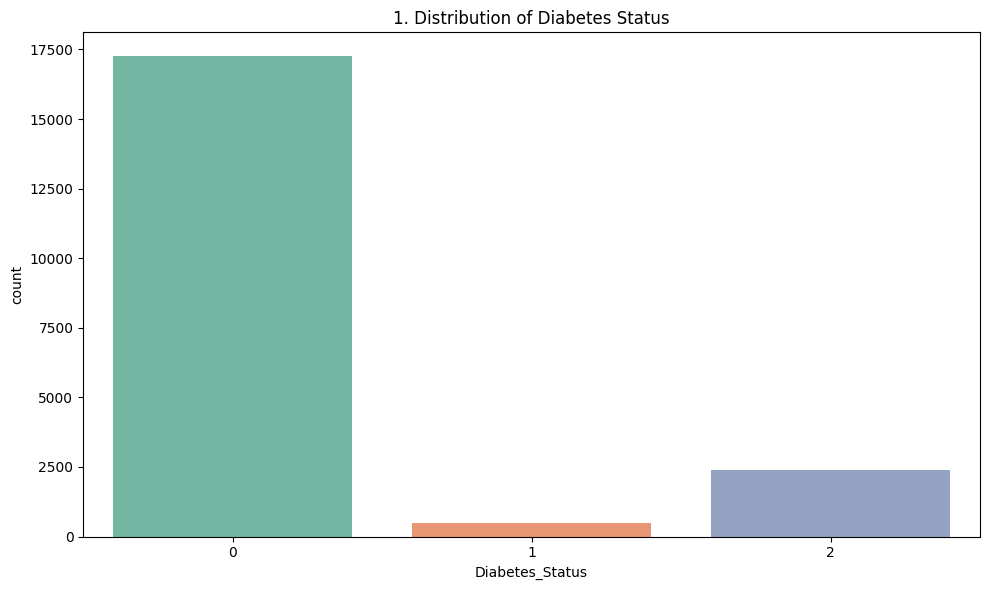

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Diabetes_Status', hue='Diabetes_Status', palette='Set2', legend=False)
plt.title(f'{plot_no}. Distribution of Diabetes Status')
show_fig()
plot_no += 1

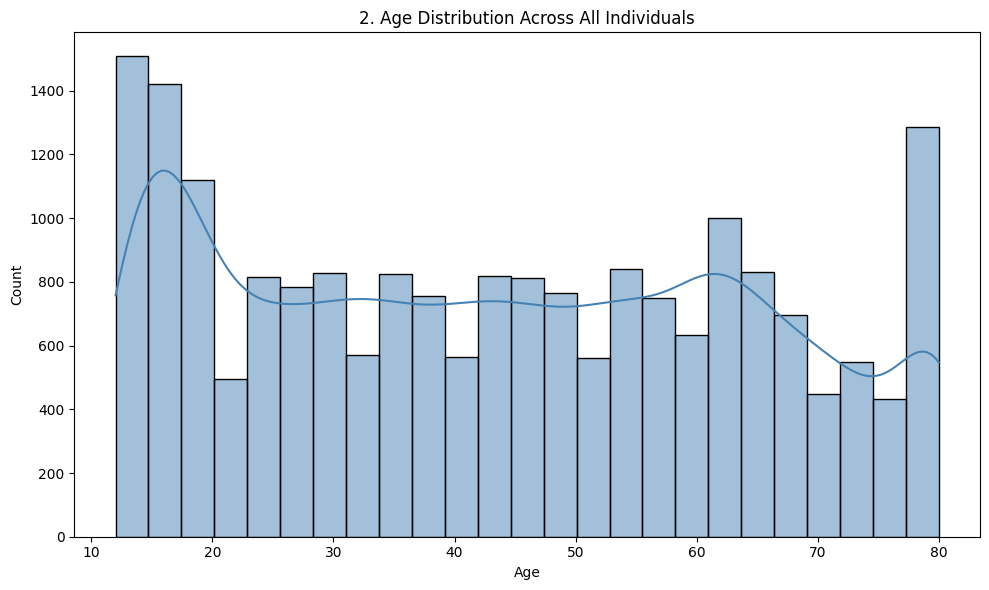

In [17]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', bins=25, kde=True, color='steelblue')
plt.title(f'{plot_no}. Age Distribution Across All Individuals')
show_fig()
plot_no += 1

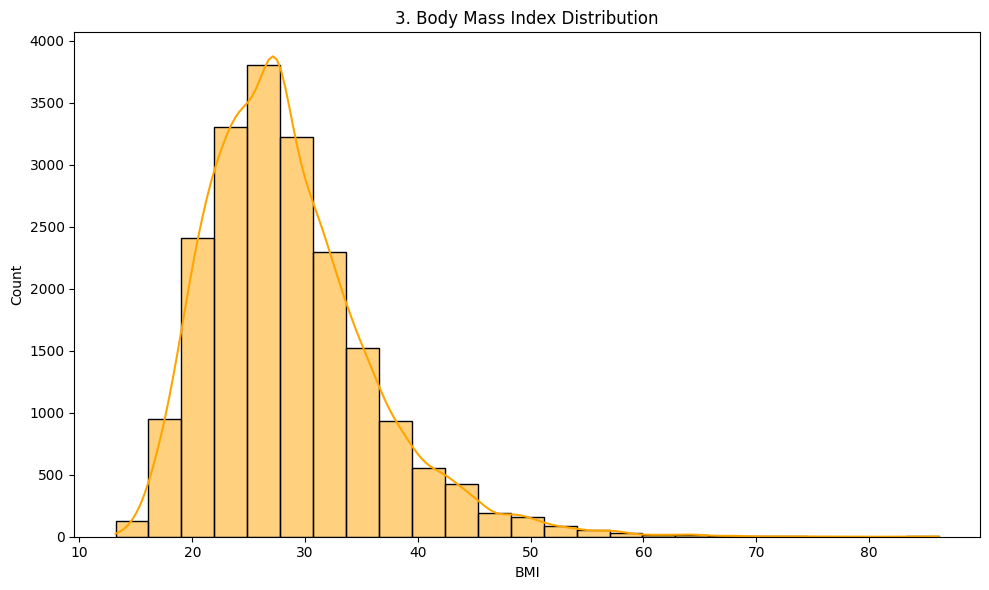

In [18]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='BMI', bins=25, kde=True, color='orange')
plt.title(f'{plot_no}. Body Mass Index Distribution')
show_fig()
plot_no += 1

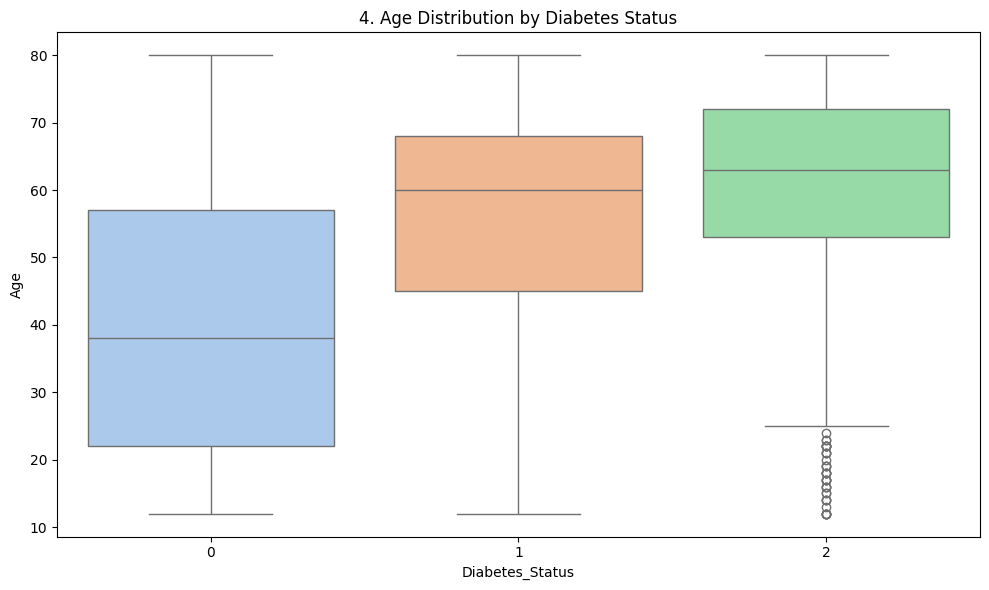

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Diabetes_Status', y='Age', hue='Diabetes_Status', palette='pastel', legend=False)
plt.title(f'{plot_no}. Age Distribution by Diabetes Status')
show_fig()
plot_no += 1

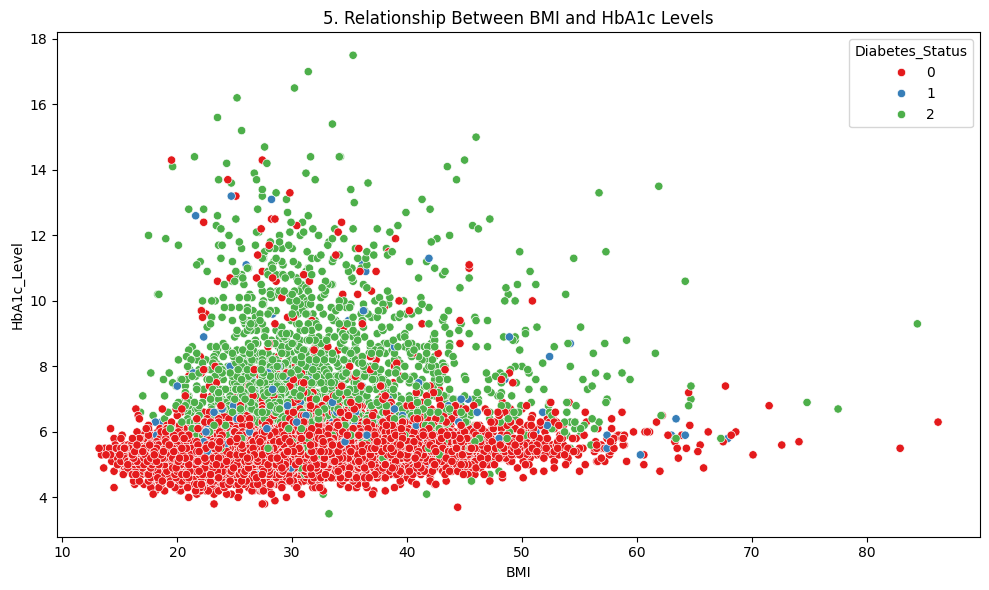

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='BMI', y='HbA1c_Level', hue='Diabetes_Status', palette='Set1')
plt.title(f'{plot_no}. Relationship Between BMI and HbA1c Levels')
show_fig()
plot_no += 1

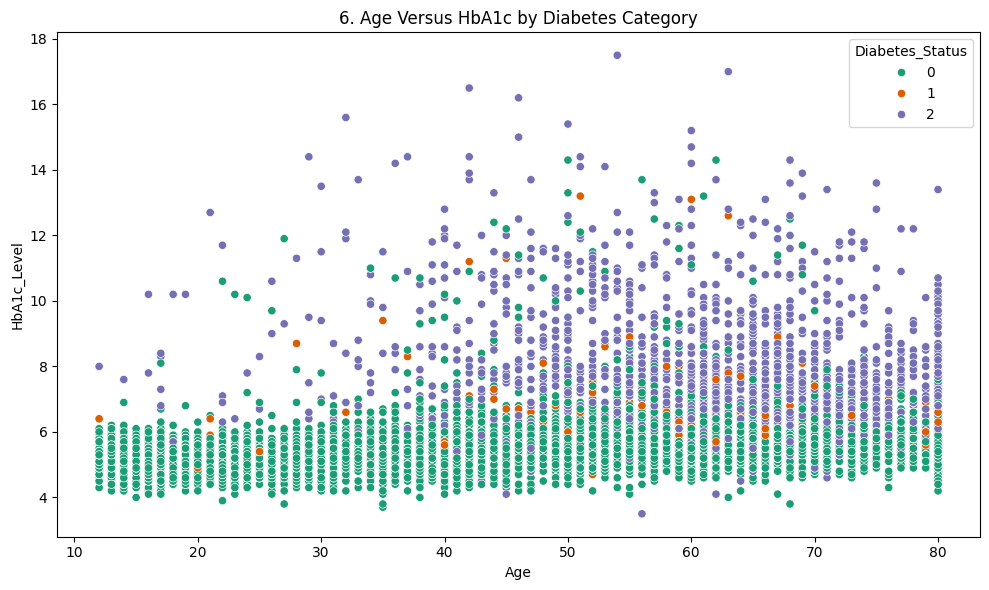

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='HbA1c_Level', hue='Diabetes_Status', palette='Dark2')
plt.title(f'{plot_no}. Age Versus HbA1c by Diabetes Category')
show_fig()
plot_no += 1

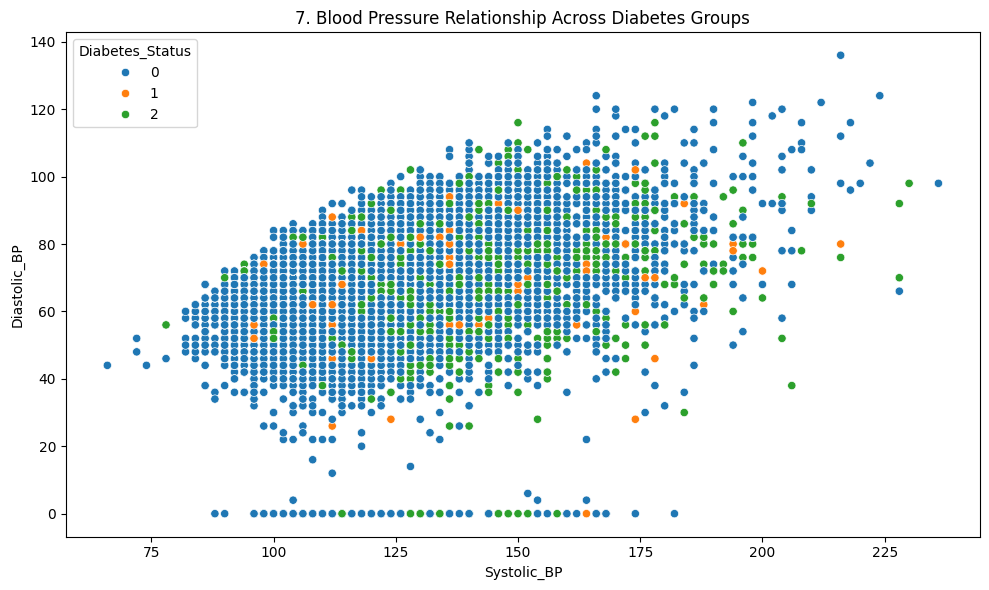

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Systolic_BP', y='Diastolic_BP', hue='Diabetes_Status', palette='tab10')
plt.title(f'{plot_no}. Blood Pressure Relationship Across Diabetes Groups')
show_fig()
plot_no += 1

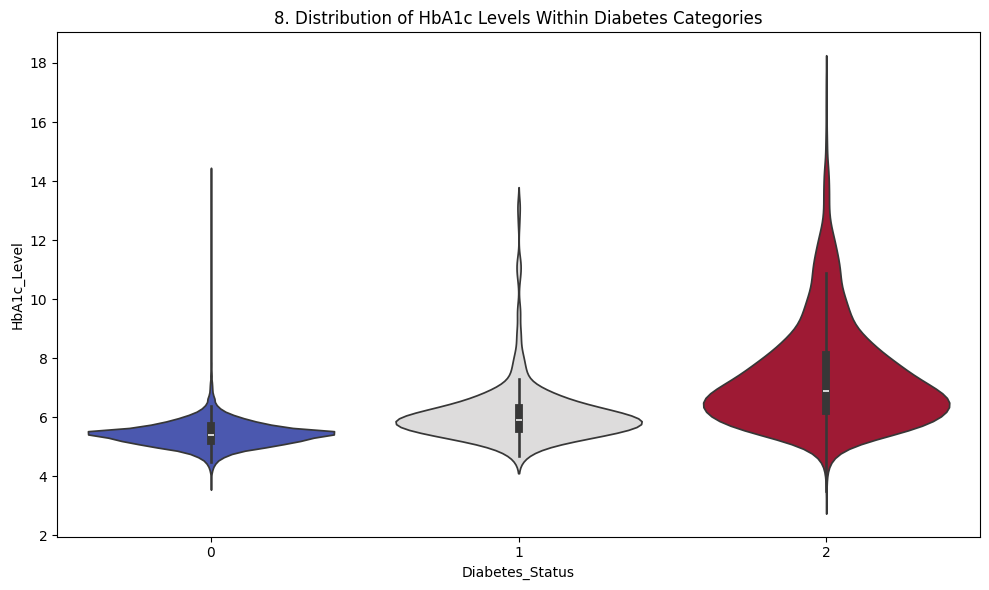

In [23]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Diabetes_Status', y='HbA1c_Level', hue='Diabetes_Status', palette='coolwarm', legend=False)
plt.title(f'{plot_no}. Distribution of HbA1c Levels Within Diabetes Categories')
show_fig()
plot_no += 1

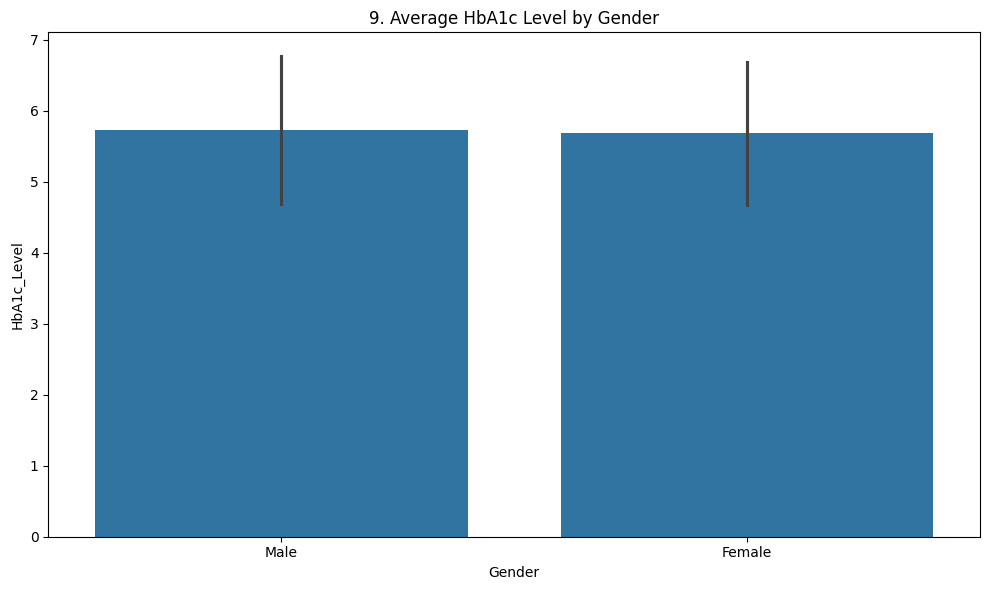

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Gender', y='HbA1c_Level', estimator='mean', errorbar='sd')
plt.title(f'{plot_no}. Average HbA1c Level by Gender')
show_fig()
plot_no += 1

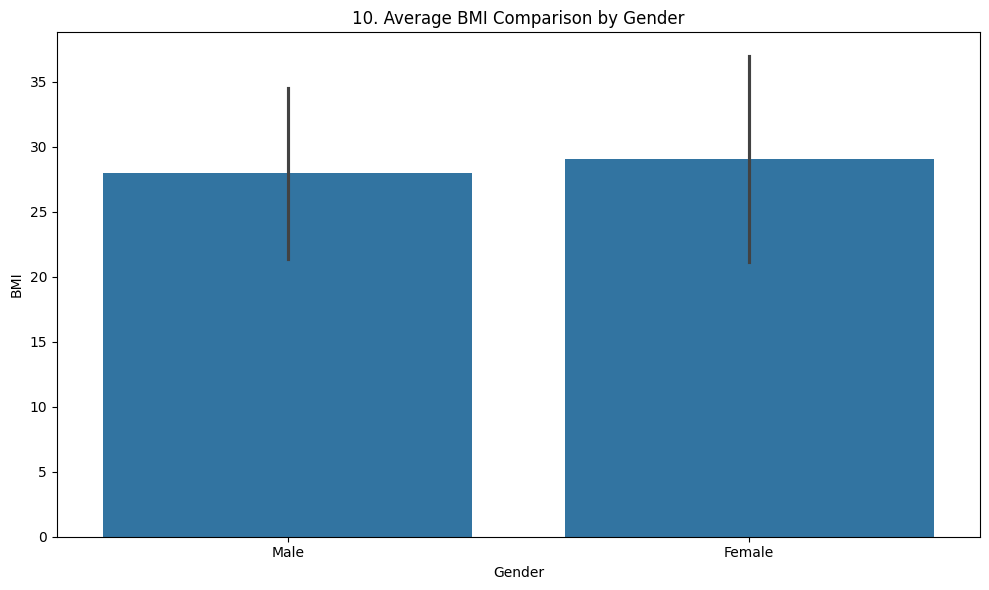

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Gender', y='BMI', estimator='mean', errorbar='sd')
plt.title(f'{plot_no}. Average BMI Comparison by Gender')
show_fig()
plot_no += 1

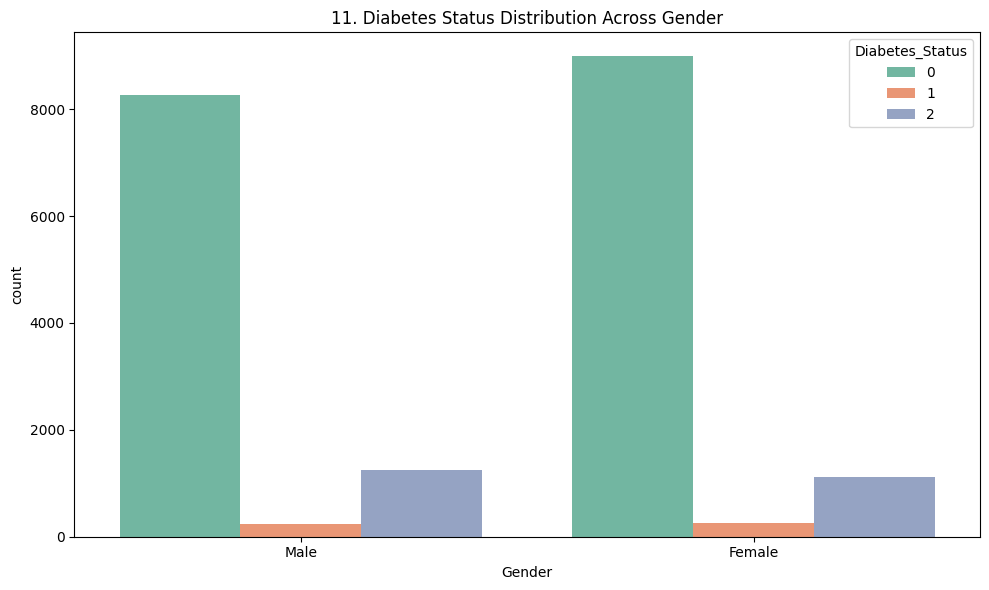

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Gender', hue='Diabetes_Status', palette='Set2')
plt.title(f'{plot_no}. Diabetes Status Distribution Across Gender')
show_fig()
plot_no += 1

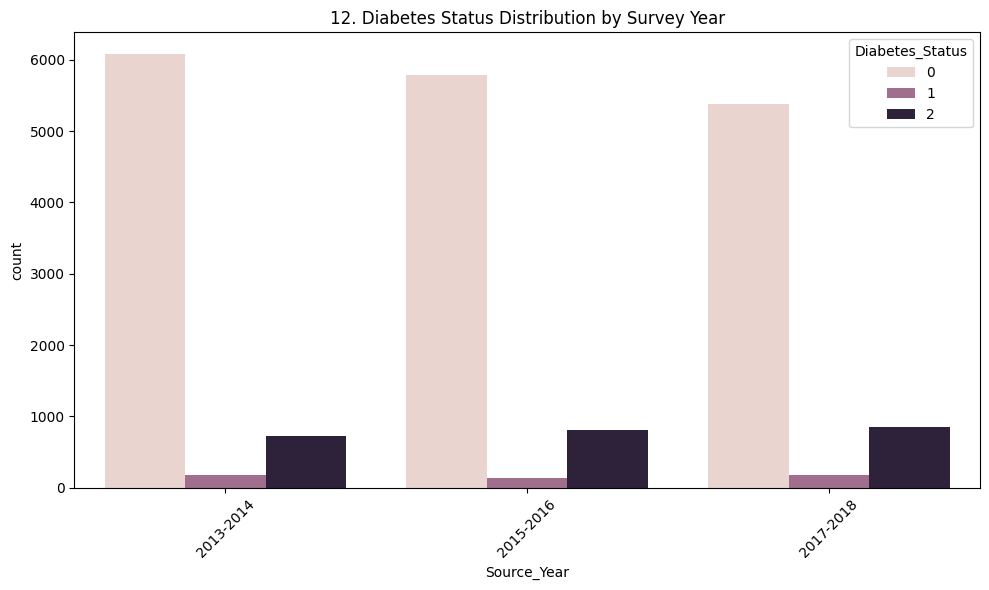

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Source_Year', hue='Diabetes_Status')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Diabetes Status Distribution by Survey Year')
show_fig()
plot_no += 1

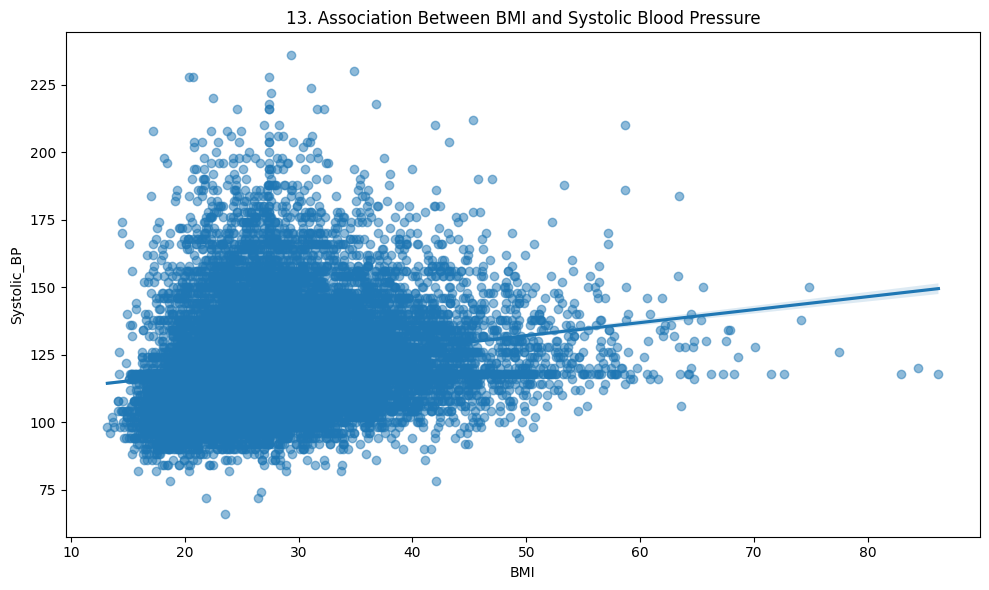

In [28]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='BMI', y='Systolic_BP', scatter_kws={'alpha':0.5})
plt.title(f'{plot_no}. Association Between BMI and Systolic Blood Pressure')
show_fig()
plot_no += 1

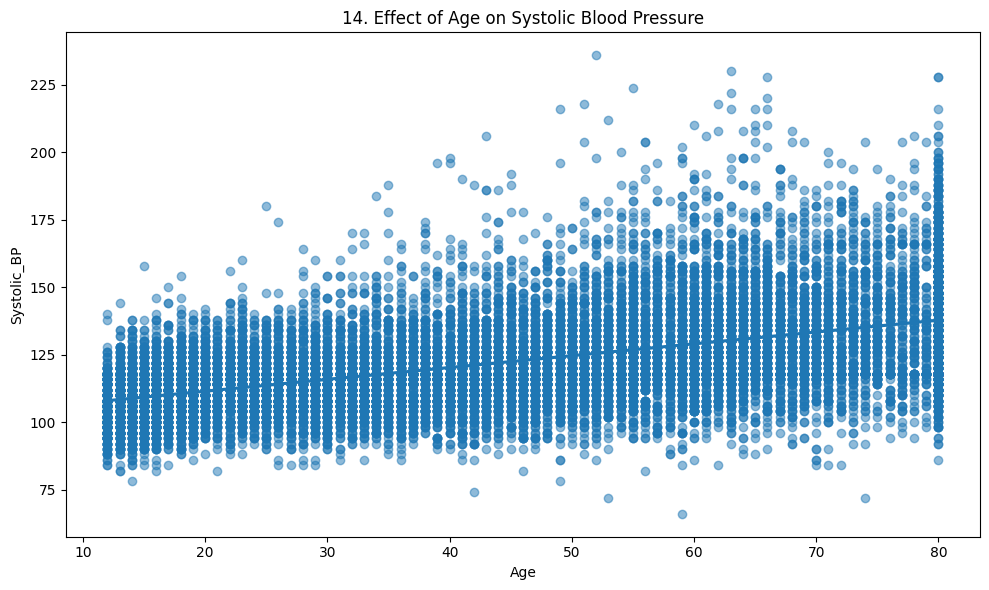

In [29]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='Age', y='Systolic_BP', scatter_kws={'alpha':0.5})
plt.title(f'{plot_no}. Effect of Age on Systolic Blood Pressure')
show_fig()
plot_no += 1

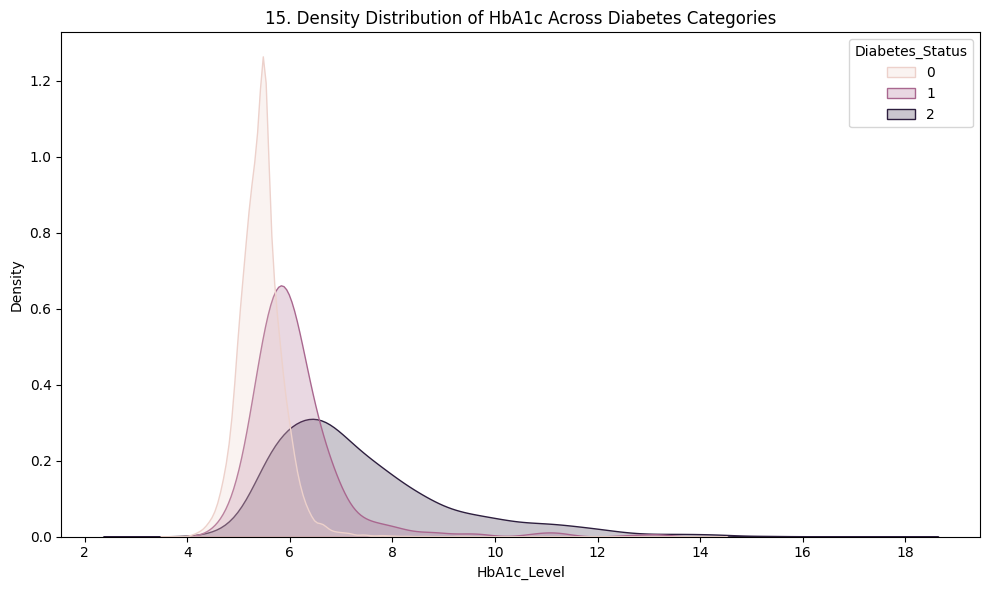

In [30]:
fig = plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='HbA1c_Level', hue='Diabetes_Status', fill=True, common_norm=False)
plt.title(f'{plot_no}. Density Distribution of HbA1c Across Diabetes Categories')
show_fig()
plot_no += 1

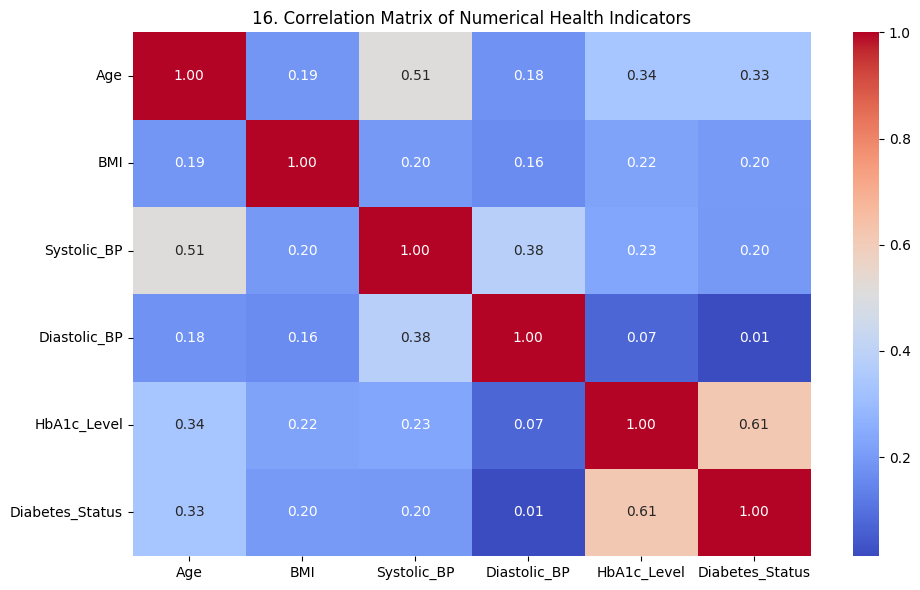

In [31]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Matrix of Numerical Health Indicators')
show_fig()
plot_no += 1

# Model Training

## Create a copy of the dataset

In [32]:
data = df.copy()

## Encode categorical columns

In [33]:
le_gender = LabelEncoder()
data['Gender'] = le_gender.fit_transform(data['Gender'])

le_year = LabelEncoder()
data['Source_Year'] = le_year.fit_transform(data['Source_Year'])

## Define features and target

In [34]:
X = data.drop('Diabetes_Status', axis=1)
y = data['Diabetes_Status']

## Split dataset into training and testing sets

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Create SVM model with feature scaling

In [36]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='rbf', C=2, gamma='scale', random_state=42))
])

## Train the model

In [37]:
model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,2
,kernel,'rbf'
,degree,3
,gamma,'scale'


## Make predictions

In [38]:
y_pred = model.predict(X_test)

## Print model accuracy

In [39]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.2%}")

Accuracy Score: 91.37%


## Display confusion matrix

<Figure size 600x500 with 0 Axes>

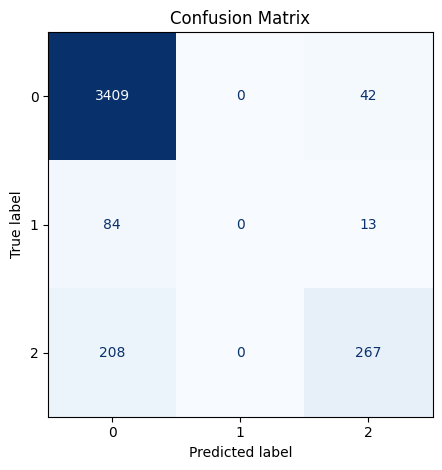

In [40]:
fig = plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues',
    colorbar=False
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()